In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam, SGD
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [ ]:
data=pd.read_csv("/content/archive (3).zip")
data

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,149996,Business,Senior,2.899,12.16,Copywriting/Drafting,Beginner,2,False,13.36,2,Allowed_With_Citation,2,3.584,66.16,High
49996,149997,STEM,Senior,2.870,2.51,Copywriting/Drafting,Intermediate,1,False,4.67,3,Actively_Encouraged,3,3.096,81.62,Medium
49997,149998,Business,Senior,3.177,15.87,Summarizing_Reading,Advanced,5,True,3.92,4,Allowed_With_Citation,5,3.605,97.21,High
49998,149999,Business,Junior,3.398,19.91,Debugging/Troubleshooting,Intermediate,5,False,7.10,5,Allowed_With_Citation,3,3.527,84.12,Medium


In [ ]:
data.isnull().sum()

,0
Student_ID,0
Major_Category,0
Year_of_Study,0
Pre_Semester_GPA,0
Weekly_GenAI_Hours,0
Primary_Use_Case,0
Prompt_Engineering_Skill,0
Tool_Diversity,0
Paid_Subscription,0
Traditional_Study_Hours,0


In [ ]:
data.dtypes

,0
Student_ID,int64
Major_Category,object
Year_of_Study,object
Pre_Semester_GPA,float64
Weekly_GenAI_Hours,float64
Primary_Use_Case,object
Prompt_Engineering_Skill,object
Tool_Diversity,int64
Paid_Subscription,bool
Traditional_Study_Hours,float64


In [ ]:
data['Major_Category'].unique()

array(['Humanities', 'Medical', 'Business', 'STEM', 'Arts'], dtype=object)

In [ ]:
data['Year_of_Study'].unique()

array(['Senior', 'Junior', 'Freshman', 'Sophomore', 'Graduate'],
      dtype=object)

In [ ]:
data['Primary_Use_Case'].unique()

array(['Copywriting/Drafting', 'Ideation', 'Summarizing_Reading',
       'Debugging/Troubleshooting', 'Direct_Answer_Generation'],
      dtype=object)

In [ ]:
data['Prompt_Engineering_Skill'].unique()

array(['Beginner', 'Advanced', 'Intermediate'], dtype=object)

In [ ]:
data["Paid_Subscription"].unique()

array([ True, False])

In [ ]:
data["Institutional_Policy"].unique()

array(['Allowed_With_Citation', 'Strict_Ban', 'Actively_Encouraged'],
      dtype=object)

In [ ]:
data['Burnout_Risk_Level'].unique()

array(['High', 'Low', 'Medium'], dtype=object)

In [ ]:
le1 = LabelEncoder()
le2 = LabelEncoder()
le3 = LabelEncoder()
le4 = LabelEncoder()
le5 = LabelEncoder()
le6 = LabelEncoder()
le7 = LabelEncoder()


In [ ]:
data['Major_Category'] = le1.fit_transform(data['Major_Category'])
data['Year_of_Study'] = le2.fit_transform(data['Year_of_Study'])
data['Primary_Use_Case'] = le3.fit_transform(data['Primary_Use_Case'])
data['Prompt_Engineering_Skill'] = le4.fit_transform(data['Prompt_Engineering_Skill'])
data['Paid_Subscription'] = le5.fit_transform(data['Paid_Subscription'])
data['Institutional_Policy'] = le6.fit_transform(data['Institutional_Policy'])
data['Burnout_Risk_Level'] = le7.fit_transform(data['Burnout_Risk_Level'])


In [ ]:
x = data.drop(['Student_ID','Burnout_Risk_Level'], axis=1)
y=data['Burnout_Risk_Level']

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
X=scaler.fit_transform(x)

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [ ]:
model = Sequential()

model.add(Dense(64, input_dim=14, activation='relu', kernel_initializer='uniform'))
model.add(Dense(46, activation='relu', kernel_initializer='uniform'))
model.add(Dense(32, activation='relu', kernel_initializer='uniform'))
model.add(Dense(16, activation='relu', kernel_initializer='uniform'))
model.add(Dense(3, activation='softmax')) # Changed to 3 units for 3 classes and softmax activation

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(loss='sparse_categorical_crossentropy', optimizer=Adam(learning_rate=0.01), metrics=['accuracy']) # Changed loss to sparse_categorical_crossentropy and optimizer to Adam

In [ ]:
history = model.fit(x_train, y_train, epochs=100, batch_size=10, validation_data=(x_test, y_test))

Epoch 1/100
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 16s 4ms/step - accuracy: 0.4987 - loss: 0.9628 - val_accuracy: 0.5094 - val_loss: 0.9386
Epoch 2/100
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 21s 4ms/step - accuracy: 0.5165 - loss: 0.9386 - val_accuracy: 0.5012 - val_loss: 0.9514
Epoch 3/100
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - accuracy: 0.5213 - loss: 0.9319 - val_accuracy: 0.5150 - val_loss: 0.9354
Epoch 4/100
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 15s 4ms/step - accuracy: 0.5228 - loss: 0.9294 - val_accuracy: 0.5094 - val_loss: 0.9524
Epoch 5/100
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - accuracy: 0.5217 - loss: 0.9297 - val_accuracy: 0.5233 - val_loss: 0.9301
Epoch 6/100
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 15s 4ms/step - accuracy: 0.5223 - loss: 0.9289 - val_accuracy: 0.5253 - val_loss: 0.9359
Epoch 7/100
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - accuracy: 0.5264 - loss: 0.9271 - val_accuracy: 0.5053 - val_loss: 0.9458
Epoch 8/100
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 15s 4ms/step - accuracy: 0.5268 -

In [ ]:
hist=history.history
hist.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

Text(0, 0.5, 'accuracy')

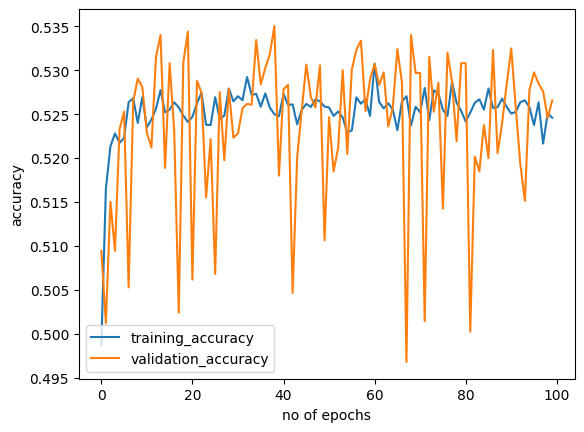

In [ ]:
plt.plot(hist['accuracy'],label='training_accuracy')
plt.plot(hist['val_accuracy'],label='validation_accuracy')
plt.legend()
plt.xlabel('no of epochs')
plt.ylabel('accuracy')

Text(0, 0.5, 'loss')

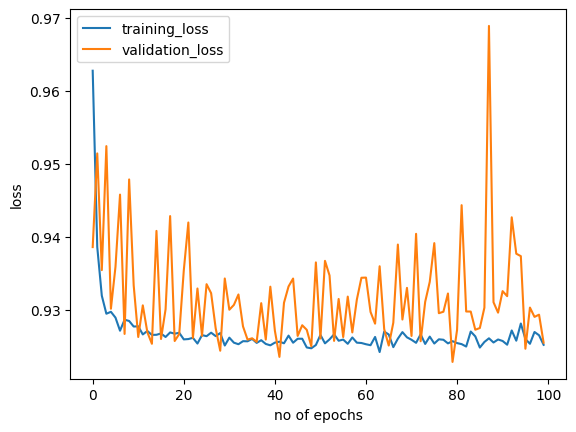

In [ ]:
plt.plot(hist['loss'],label='training_loss')
plt.plot(hist['val_loss'],label='validation_loss')
plt.legend()
plt.xlabel('no of epochs')
plt.ylabel('loss')

In [ ]:
y_pred=model.predict(x_test)
y_pred

391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([[0.19720963, 0.33131656, 0.47147387],
       [0.25915906, 0.26468083, 0.47616014],
       [0.47497988, 0.1158602 , 0.40916002],
       ...,
       [0.04880546, 0.5839296 , 0.36726493],
       [0.09518878, 0.47500584, 0.42980537],
       [0.10059328, 0.46503252, 0.43437415]], dtype=float32)

In [ ]:
import numpy as np

In [ ]:
new_data=np.array([
    [2,1,3.4,12.5,1,0,3,1,15.0,4,1,2,3.2,1]
])

prediction=model.predict(new_data)
print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
[[0.83837205 0.01061399 0.15101399]]
